In [80]:
# Importy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Wczytanie danych

In [46]:
# Wczytanie danych
df = pd.read_csv("sleep_health_dataset.csv")

# Kształt zbioru i spradzenie danych
print(f"Kształt zbioru: {df.shape}\n")
df.head()

Kształt zbioru: (100000, 32)



,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [10]:
# Statystyki kolumn: typy, wartości niepuste, ilość danych
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

In [12]:
# Statystyki kolumn liczbowych
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [29]:
# Przegląd kolumn kategorycznych
kolumny_kategoryczne = df.select_dtypes(include="str").columns

for kol in kolumny_kategoryczne:
    print(f"\n-- {kol} ({df[kol].nunique()} unikalnych) --")
    print(df[kol].value_counts())
    print("-" * 32)
    print(f"Suma liczności: {df[kol].value_counts().sum()}")


-- gender (3 unikalnych) --
gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64
--------------------------------
Suma liczności: 100000

-- occupation (12 unikalnych) --
occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Doctor                7868
Retired               7036
Sales                 7017
Freelancer            7016
Driver                6996
Homemaker             5923
Lawyer                5004
Name: count, dtype: int64
--------------------------------
Suma liczności: 100000

-- country (15 unikalnych) --
country
USA            20050
India          17840
Japan           8089
UK              8024
Brazil          7146
Germany         6026
Canada          4995
France          4982
Australia       4948
Italy           4018
South Korea     3971
Mexico          3888
Netherlands     3040
Spain           2011
Sweden           972
Name: count, dtype: int64
---

**Wnioski po wczytaniu danych i wstępnej analizie:**
- Zbiór posiada 100000 wierszy i 32 kolumny.
- Zbiór nie zawiera brakujących wartości - wszytkie kolumny mają po 100000 rekordów.
- Zbiór pochodzi ze strony Kaggle i wygląda na dobrze przygotowany do analizy.
- Zakresy liczbowe wyglądają realnie (np. wiek:  18-69, BMI: 16-45, temperatura 15-28).
- Kategorie tekstowe są czyste i ujednolicone - wszytkie zaczynają się od dużych liter i bez literówek.

*Dlatego główną częścią przygotowania danych będą konwersje typów i utworzenie kolumn pochodnych, a nie usuwanie braków.*

# Czyszczenie i przygotowanie danych

## Obsługa braków

Zbiór nie zawiera brakujących wartości (potwierdzone wcześniej: `isnull().sum()` = 0),więc obsługa braków nie jest tu potrzebna. Poniżej pokazuję jednak, jak podszedłbym do tego problemu, gdyby braki wystąpiły. Cała demonstracja działa na kopii danych (`df_demo`) i nie wpływa na główny zbiór, który jest kompletny.

In [53]:
# Utworzenie kopi zbioru
df_demo = df.copy()

# Wstawienie braków w kilku kolumnach.
df_demo.loc[df_demo.sample(frac=0.05, random_state=42).index, "bmi"] = np.nan
df_demo.loc[df_demo.sample(frac=0.03, random_state=1).index, "stress_score"] = np.nan
df_demo.loc[df_demo.sample(frac=0.02, random_state=2).index, "occupation"] = np.nan

# Wyświetlenie braków
print("Braki w zbiorze dodatkowym:")
print(df_demo[["bmi", "stress_score", "occupation"]].isnull().sum())

Braki w zbiorze dodatkowym:
bmi             5000
stress_score    3000
occupation      2000
dtype: int64


In [54]:
# Kolumny liczbowe - wypełnienie mediany
df_demo["bmi"] = df_demo["bmi"].fillna(df_demo["bmi"].median())
df_demo["stress_score"] = df_demo["stress_score"].fillna(df_demo["stress_score"].median())

# Kolumna kategoryczna - wyoełnienie modą
df_demo["occupation"] = df_demo["occupation"].fillna(df_demo["occupation"].mode()[0])

# Wyświetlenie braków
print("Braki po wypełnieniu:")
print(df_demo[["bmi", "stress_score", "occupation"]].isnull().sum())

Braki po wypełnieniu:
bmi             0
stress_score    0
occupation      0
dtype: int64


In [56]:
# Utworzenie kopi zbioru
df_demo2 = df.copy()

# Wstawienie braków w bmi
df_demo2.loc[df_demo2.sample(frac=0.05, random_state=42).index, "bmi"] = np.nan

print("Przed usunięciem:", df_demo2.shape)

# Usuwa wiersze, w których brakuje wartości w kolumnie bmi
df_demo2 = df_demo2.dropna(subset=["bmi"])

print("Po usunięciu:  ", df_demo2.shape)
print("Usunięto wierszy:", 100000 - len(df_demo2))

Przed usunięciem: (100000, 32)
Po usunięciu:   (95000, 32)
Usunięto wierszy: 5000


W zbiorze nie występują braki, dlatego powyższą obsługę przeprowadziłem na kopii danych (`df_demo`) z celowo wstawionymi wartościami `NaN` — wyłącznie po to, żeby pokazać technikę. Główny zbiór pozostaje kompletny.

Braki najpierw sprawdzam (`isnull().sum()`), a dopiero potem decyduję, co z nimi zrobić. Wybór strategii zależy od skali problemu: przy niewielkiej liczbie braków (poniżej ~5%) można usunąć wiersze (`dropna`), natomiast gdy braków jest dużo, lepiej je wypełnić (`fillna`), żeby nie tracić danych.
Kolumny liczbowe wypełniam medianą — jest odporna na wartości odstające i sprawdza się lepiej niż średnia — a kolumny kategoryczne modą, czyli najczęstszą wartością. Jeśli braki obejmują ponad połowę kolumny, warto rozważyć usunięcie jej w całości.

## Konwersje typów

In [57]:
# Konwersja kolumn logicznych z wartościami 0/1 na wartości Tak/Nie i zmiana na typ category.
kolumny_binarne = ["exercise_day", "sleep_aid_used", "shift_work", "felt_rested"]

for kol in kolumny_binarne:
    if pd.api.types.is_numeric_dtype(df[kol]):
        df[kol] = df[kol].map({0: "Nie", 1: "Tak"}).astype("category")

# Sprawdzenie
df[kolumny_binarne].head()

,exercise_day,sleep_aid_used,shift_work,felt_rested
0,Nie,Nie,Nie,Nie
1,Tak,Tak,Nie,Tak
2,Tak,Nie,Tak,Nie
3,Tak,Nie,Nie,Nie
4,Nie,Nie,Nie,Nie


In [58]:
# Zamiana kolumn tekstowych na typ category - oszczędność pamięci.
kolumny_kategoryczne = ["gender", "occupation", "country", "chronotype", "mental_health_condition", "season", "day_type", "sleep_disorder_risk"]

for kol in kolumny_kategoryczne:
    df[kol] = df[kol].astype("category")

# Sprawdzenie - niższe zużycie pamięci
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   person_id                    100000 non-null  int64   
 1   age                          100000 non-null  int64   
 2   gender                       100000 non-null  category
 3   occupation                   100000 non-null  category
 4   bmi                          100000 non-null  float64 
 5   country                      100000 non-null  category
 6   sleep_duration_hrs           100000 non-null  float64 
 7   sleep_quality_score          100000 non-null  float64 
 8   rem_percentage               100000 non-null  float64 
 9   deep_sleep_percentage        100000 non-null  float64 
 10  sleep_latency_mins           100000 non-null  int64   
 11  wake_episodes_per_night      100000 non-null  int64   
 12  caffeine_mg_before_bed       100000 non-null  int64   
 

Kolumny logiczne (0/1) zamieniłem na czytelniejsze etykiety Tak/Nie, co ułatwi implementacje filtrów i legend na dashboardzie. Kolumny tekstowe o powtarzalnych wartościach przekonwertowałem na typ `category`, który pandas przechowuje jako liczby z mapą etykiet, co przy 100 000 wierszy realnie zmniejsza zużycie pamięci (z 29,3 MB do ok. 16,4 MB, czyli blisko 45%).

## Transformacje

In [59]:
# Sprawdzenie skośności kolumn liczbowych
kolumny_liczbowe = df.select_dtypes(include="number").drop(columns=["person_id"])
skosnosc = kolumny_liczbowe.skew().sort_values(ascending=False)

print("Skośność kolumn liczbowych:")
print(skosnosc.round(2))

Skośność kolumn liczbowych:
caffeine_mg_before_bed         2.38
alcohol_units_before_bed       1.93
nap_duration_mins              1.21
screen_time_before_bed_mins    1.15
age                            0.55
wake_episodes_per_night        0.45
sleep_latency_mins             0.24
sleep_duration_hrs             0.22
steps_that_day                 0.14
room_temperature_celsius       0.13
bmi                            0.07
heart_rate_resting_bpm         0.01
weekend_sleep_diff_hrs        -0.05
sleep_quality_score           -0.09
deep_sleep_percentage         -0.11
rem_percentage                -0.11
work_hours_that_day           -0.16
cognitive_performance_score   -0.29
stress_score                  -0.36
dtype: float64


Najbardziej skośna zmienna to `caffeine_mg_before_bed`. Większość osób nie przyjmuje kofeiny przed snem (dużo zer), a nieliczne przyjmują jej bardzo dużo, co daje długi prawy ogon. To dobry kandydat do transformacji logarytmicznej.

In [63]:
# Transformacja logarytmiczna
df["caffeine_log"] = np.log1p(df["caffeine_mg_before_bed"])
print("Skośność przed:", round(df["caffeine_mg_before_bed"].skew(), 2))
print("Skośność po:   ", round(df["caffeine_log"].skew(), 2))

Skośność przed: 2.38
Skośność po:    0.71


Kofeina miała najbardziej skośny rozkład (2.38), ponieważ większość osób ma zero, a kolejna część bardzo dużo, stąd długi ogon. Użyłem log1p (log(1+x), bo w kolumnie są zera i zwykły log by się wywalił), co ścisnęło ogon i obniżyło skośność do 0,71. Wynik dodałem w nowej kolumnie `caffeine_log`, a oryginalną kolumnę zostawiłem nienaruszoną.

## Kolumny pochodne

Na podstawie istniejących kolumn tworzę nowe zmienne, które ułatwią analizę i grupowanie na dashboardzie — przedziały wiekowe, kategorie BMI oraz proste flagi.

In [64]:
# Wiek dzielimy na przedziały
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 29, 44, 59, 100],
    labels=["18-29", "30-44", "45-59", "60+"]
)

print(df["age_group"].value_counts().sort_index())

age_group
18-29    37948
30-44    42189
45-59    17626
60+       2237
Name: count, dtype: int64


In [66]:
# BMI zamieniamy na kategorie zdrowotne (WHO)
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Niedowaga", "Norma", "Nadwaga", "Otyłość"]
)

print(df["bmi_category"].value_counts())

bmi_category
Nadwaga      40328
Norma        35066
Otyłość      20216
Niedowaga     4390
Name: count, dtype: int64


In [70]:
# Czas przed ekranem przed snem
df["high_screen"] = (df["screen_time_before_bed_mins"] > 60).map({True: "Tak", False: "Nie"}).astype("category")

# Czy wystarczająca ilość snu
df["enough_sleep"] = (df["sleep_duration_hrs"] >= 7).map({True: "Tak", False: "Nie"}).astype("category")

print("Czas przed ekranem:\n", df["high_screen"].value_counts(), "\n")
print("Wystarczająca ilość snu:\n", df["enough_sleep"].value_counts())

Czas przed ekranem:
 high_screen
Nie    59277
Tak    40723
Name: count, dtype: int64 

Wystarczająca ilość snu:
 enough_sleep
Nie    68127
Tak    31873
Name: count, dtype: int64


Z wieku i BMI zrobiłem przedziały przez pd.cut. Dzięki temu łatwiej będzie analizować grupy niż pojedyncze lata, a progi BMI wziąłem wprost z WHO. Dodałem też dwie flagi Tak/Nie: czas przed ekranem przed snem (>60 min) i wystarczająca ilość snu (>=7h). Od razu widać, że tylko 1/3 osób śpi wystarczająco długo, a 60% ma nadwagę lub otyłość.

# Eksploracyjna analiza danych (EDA)

## Co wpływa na jakość snu?

Sprawdzam, które czynniki stylu życia i zdrowia są powiązane z jakością snu.
Zacznę od korelacji zmiennych liczbowych - `sleep_quality_score`.

In [72]:
# Korelację kolumn liczbowych z sleep_quality_score.
kolumny_liczbowe = df.select_dtypes(include="number")
korelacje = kolumny_liczbowe.corr()["sleep_quality_score"].drop("sleep_quality_score")

# Korelacje
print("Korelacja z jakością snu:")
print(korelacje.sort_values().round(3))

Korelacja z jakością snu:
stress_score                  -0.639
wake_episodes_per_night       -0.381
work_hours_that_day           -0.369
sleep_latency_mins            -0.293
alcohol_units_before_bed      -0.081
screen_time_before_bed_mins   -0.079
heart_rate_resting_bpm        -0.066
bmi                           -0.057
caffeine_mg_before_bed        -0.050
caffeine_log                  -0.043
age                           -0.025
room_temperature_celsius      -0.023
nap_duration_mins             -0.016
weekend_sleep_diff_hrs        -0.006
person_id                      0.002
steps_that_day                 0.014
deep_sleep_percentage          0.091
rem_percentage                 0.254
sleep_duration_hrs             0.646
cognitive_performance_score    0.860
Name: sleep_quality_score, dtype: float64


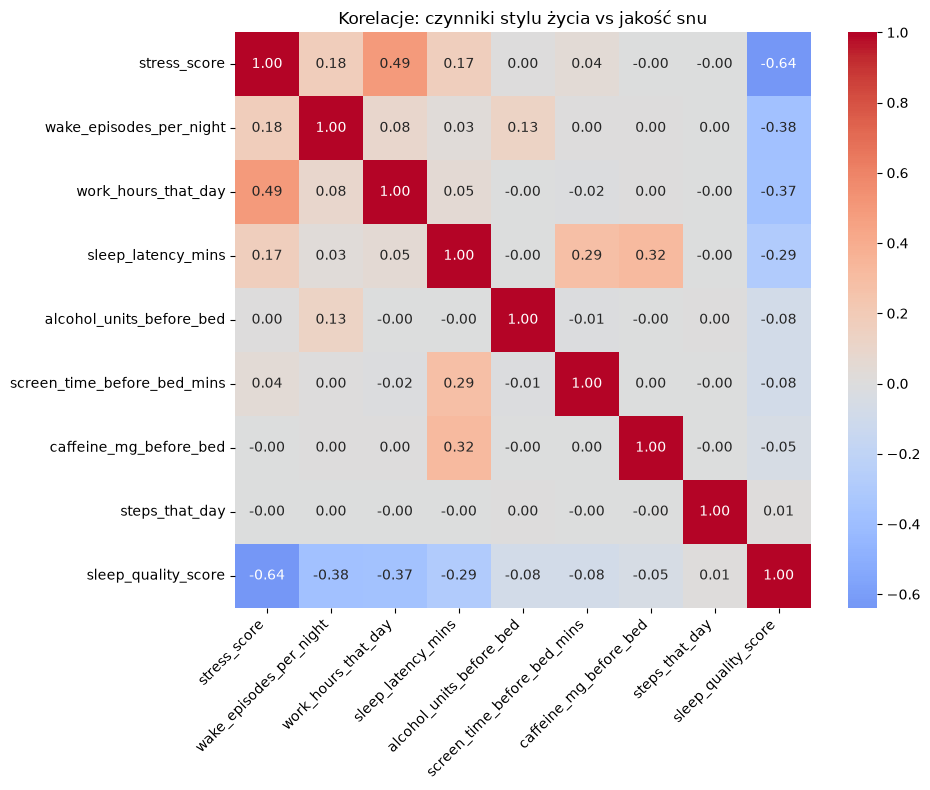

In [79]:
# Czynniki stylu życia/zdrowia, a jakość snu jako wynik.
kolumny_akt1 = ["stress_score", "wake_episodes_per_night", "work_hours_that_day", "sleep_latency_mins", "alcohol_units_before_bed", "screen_time_before_bed_mins", "caffeine_mg_before_bed", "steps_that_day", "sleep_quality_score"]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[kolumny_akt1].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Korelacje: czynniki stylu życia vs jakość snu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Na wykresie możemy wyodrębnić trzy grupy zmiennych:
- czynniki stylu życia i zdrowia (u góry, ujemne — najsilniejszy stres −0.64)
- cechy samego snu (długość, REM)
- skutki snu (wydajność poznawcza 0.86, najsilniejsza dodatnia).

Tutaj skupiam się na czynnikach wpływających na sen, dlatego poniższa heatmapa pokazuje tylko tę grupę.

## Jakość snu vs stres

In [91]:
# Podział stresu na grupy
df["stress_group"] = pd.cut(
    df["stress_score"],
    bins=[0, 3, 5, 7, 10],
    labels=["Niski", "Umiarkowany", "Wysoki", "Bardzo wysoki"]
)
print(df["stress_group"].value_counts().sort_index())

stress_group
Niski             6130
Umiarkowany      24589
Wysoki           48905
Bardzo wysoki    20376
Name: count, dtype: int64


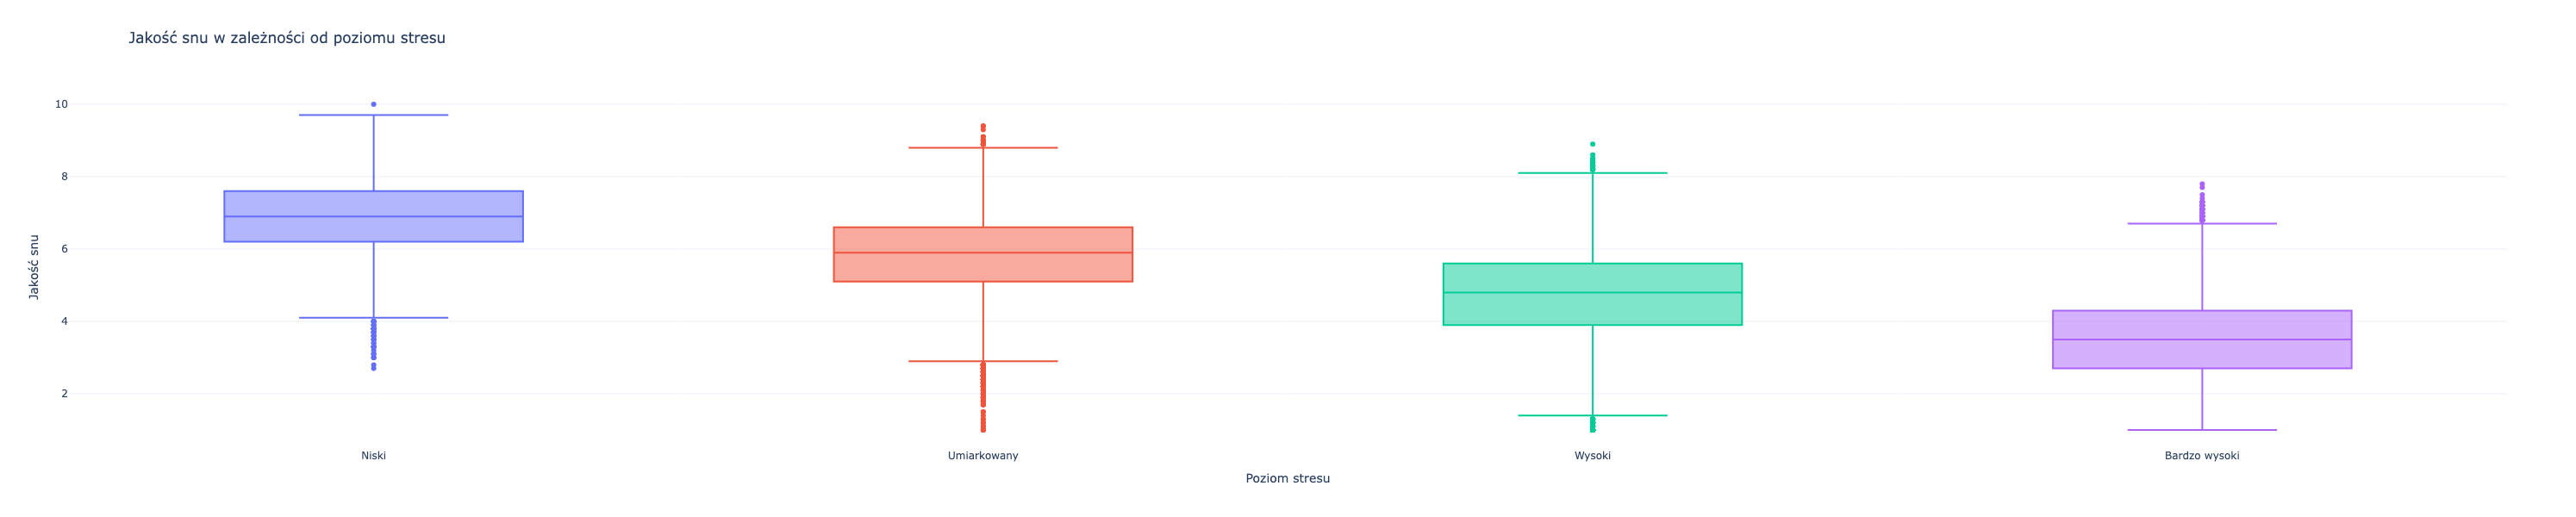

In [105]:
# Rysowanie wykresu - boxplot
fig = px.box(
    df,
    x="stress_group",
    y="sleep_quality_score",
    color="stress_group",
    category_orders={
        "stress_group": ["Niski", "Umiarkowany", "Wysoki", "Bardzo wysoki"]
    },
    labels={
        "stress_group": "Poziom stresu",
        "sleep_quality_score": "Jakość snu"
    },
    title="Jakość snu w zależności od poziomu stresu"
)
fig.update_layout(
    template="plotly_white",
    width=1600,
    height=600,
    showlegend=False
)
fig.show()

Jakość snu wyraźnie spada wraz ze wzrostem stresu. Mediana obniża się schodkowo od 6.9 przy niskim stresie do 3.5 przy bardzo wysokim stresie.
    
To potwierdza najsilniejszą korelację z heatmapy - im wyższy stres, tym gorszy sen.

## Zawody vs jakość snu

In [95]:
# Sen wg. zawodu
sen_wg_zawodu = df.groupby("occupation", observed=True)["sleep_quality_score"].mean().sort_values()
print("Średnia jakość snu wg zawodu:")
print(sen_wg_zawodu.round(2))

Średnia jakość snu wg zawodu:
occupation
Lawyer               4.00
Nurse                4.11
Doctor               4.26
Driver               4.30
Student              4.58
Manager              4.68
Sales                4.89
Software Engineer    5.03
Teacher              5.14
Freelancer           5.65
Homemaker            5.68
Retired              6.62
Name: sleep_quality_score, dtype: float64


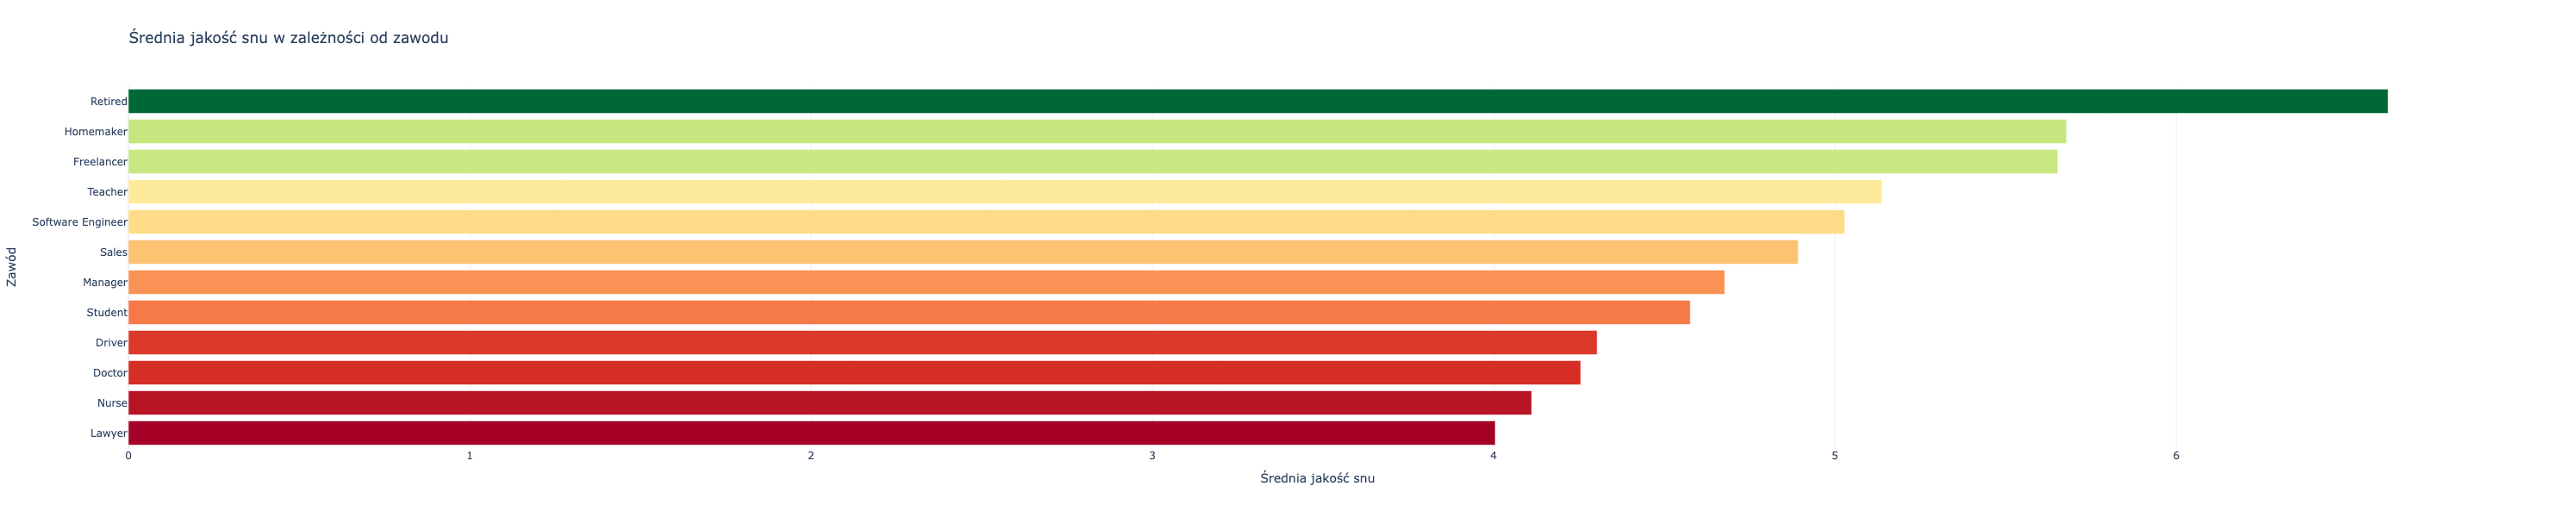

In [103]:
# Średnia jakość snu wg zawodu
srednie = (
    df.groupby("occupation", observed=True)["sleep_quality_score"]
    .mean()
    .sort_values()
    .reset_index()
)

fig = px.bar(
    srednie,
    x="sleep_quality_score",
    y="occupation",
    orientation="h",
    color="sleep_quality_score",
    color_continuous_scale="RdYlGn",
    labels={
        "sleep_quality_score": "Średnia jakość snu",
        "occupation": "Zawód"
    },
    title="Średnia jakość snu w zależności od zawodu"
)
fig.update_layout(
    template="plotly_white",
    width=1600,
    height=600,
    coloraxis_showscale=False
)
fig.show()

Zawód wyraźnie wiąże się z jakością snu. 

Najlepiej śpią emeryci, gospodynie i freelancerzy, czyli grupy z większą kontrolą nad własnym czasem. 

Najgorzej wypadają prawnicy, pielęgniarki, lekarze i kierowcy, a więc zawody stresujące, odpowiedzialne lub zmianowe. 

Pokrywa się to z wcześniejszym wnioskiem, że to stres najsilniej pogarsza sen.

## Jak sen wpływa na wydajność poznawczą?

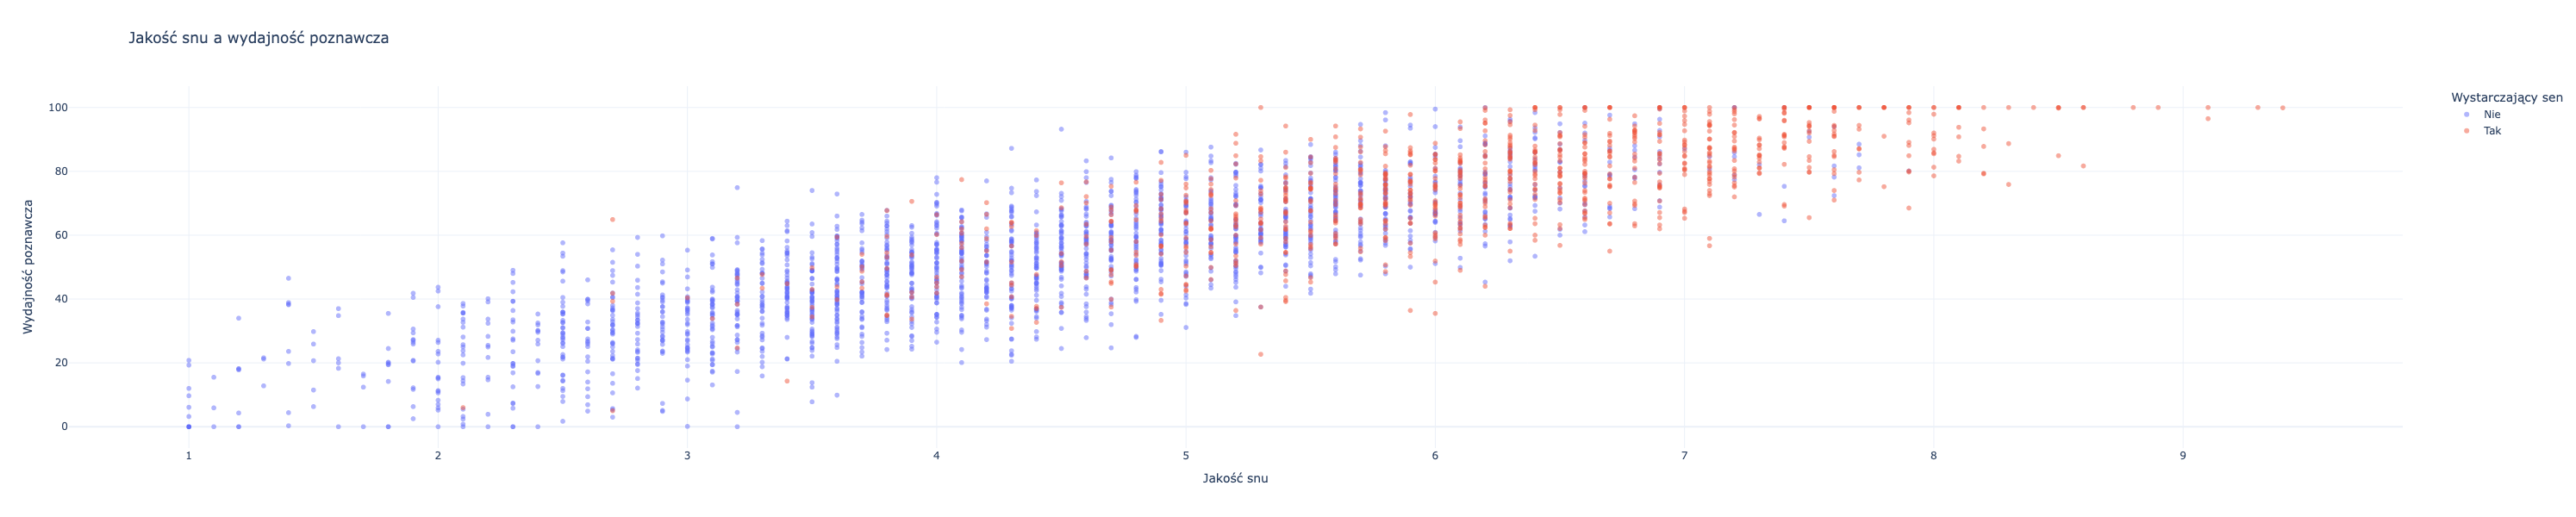

In [110]:
# Najsilniejsza zależność w zbiorze: jakość snu vs wydajność poznawcza.
# Próbka 3000, żeby wykres był czytelny i szybki.
probka = df.sample(3000, random_state=42)

fig = px.scatter(
    probka,
    x="sleep_quality_score",
    y="cognitive_performance_score",
    color="enough_sleep",
    opacity=0.5,
    labels={
        "sleep_quality_score": "Jakość snu",
        "cognitive_performance_score": "Wydajność poznawcza",
        "enough_sleep": "Wystarczający sen"
    },
    title="Jakość snu a wydajność poznawcza"
)
fig.update_layout(
    template="plotly_white",
    width=1600,
    height=600
)
fig.show()

Widać bardzo silną, wznoszącą zależność — im lepsza jakość snu, tym wyższa wydajność poznawcza.
    
Przy niskiej jakości snu wydajność rzadko przekracza 40, natomiast przy jakości powyżej 7 skupia się w okolicach 80–100.
    
Dodatkowo widać, że osoby śpiące wystarczająco długo (≥7h, kolor pomarańczowy) gromadzą się w prawym górnym rogu — dobra jakość i wystarczająca długość snu idą w parze i razem przekładają się na lepsze funkcjonowanie.

## Histogram wydajności poznawczej

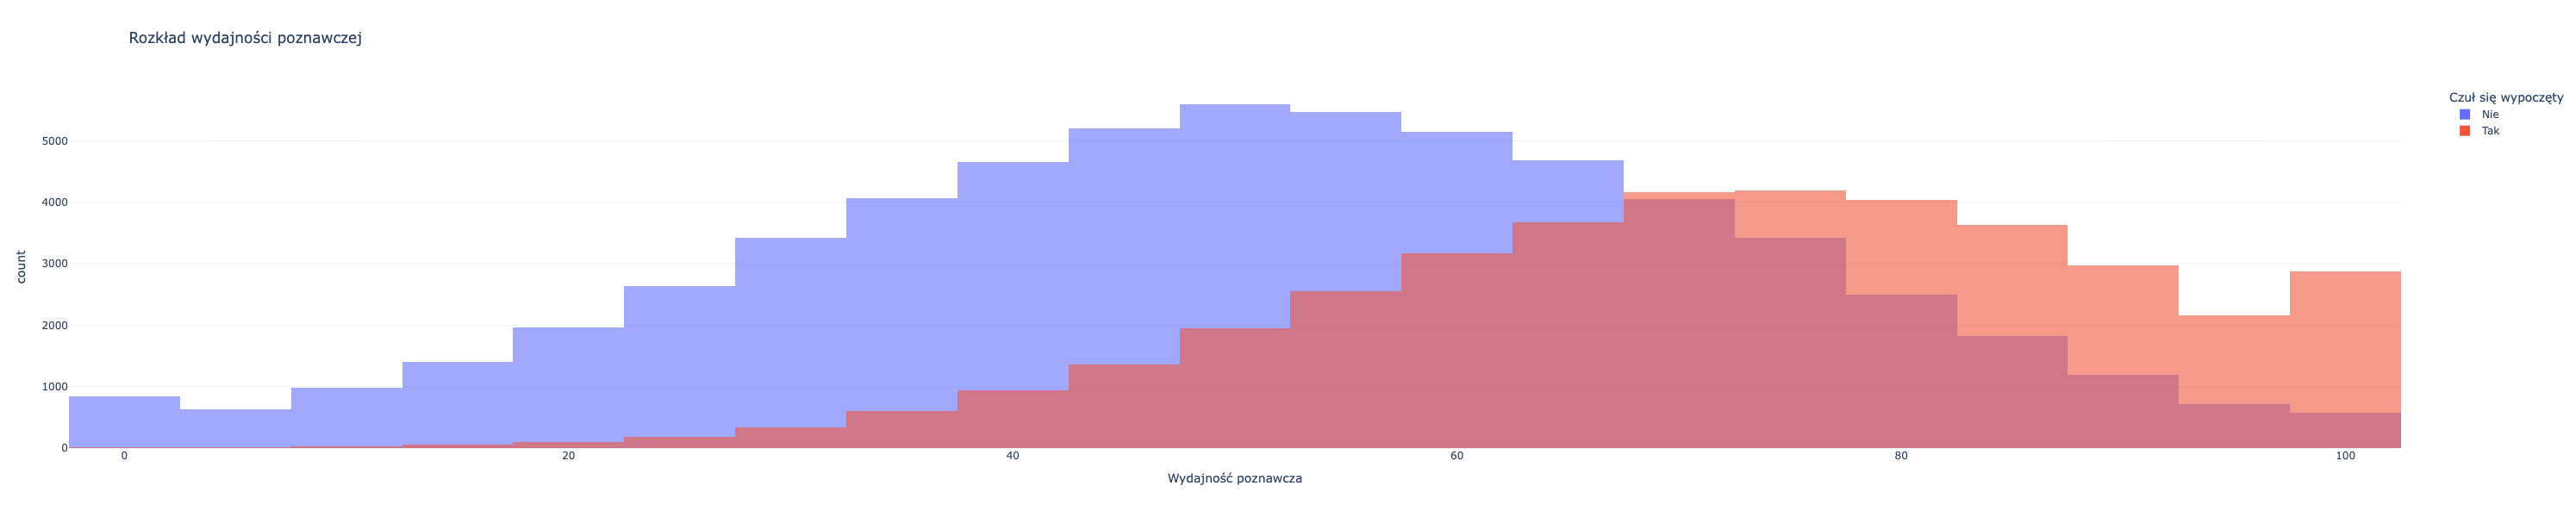

In [114]:
# Rozkład wydajności poznawczej
fig = px.histogram(
    df,
    x="cognitive_performance_score",
    color="felt_rested",
    nbins=40,
    barmode="overlay",
    opacity=0.6,
    labels={
        "cognitive_performance_score": "Wydajność poznawcza",
        "felt_rested": "Czuł się wypoczęty"
    },
    title="Rozkład wydajności poznawczej"
)
fig.update_layout(template="plotly_white", width=1600, height=600)
fig.show()

Rozkłady wyraźnie się rozdzielają. 
    
Osoby, które nie czuły się wypoczęte (niebieski), mają wydajność skupioną w dolnej połowie skali, natomiast wypoczęte (pomarańczowy) są przesunięte w prawo.
    
Poczucie wypoczęcia nie jest więc tylko subiektywnym wrażeniem, a pokrywa się z realnie wyższą wydajnością poznawczą.

## Zaburzenia snu

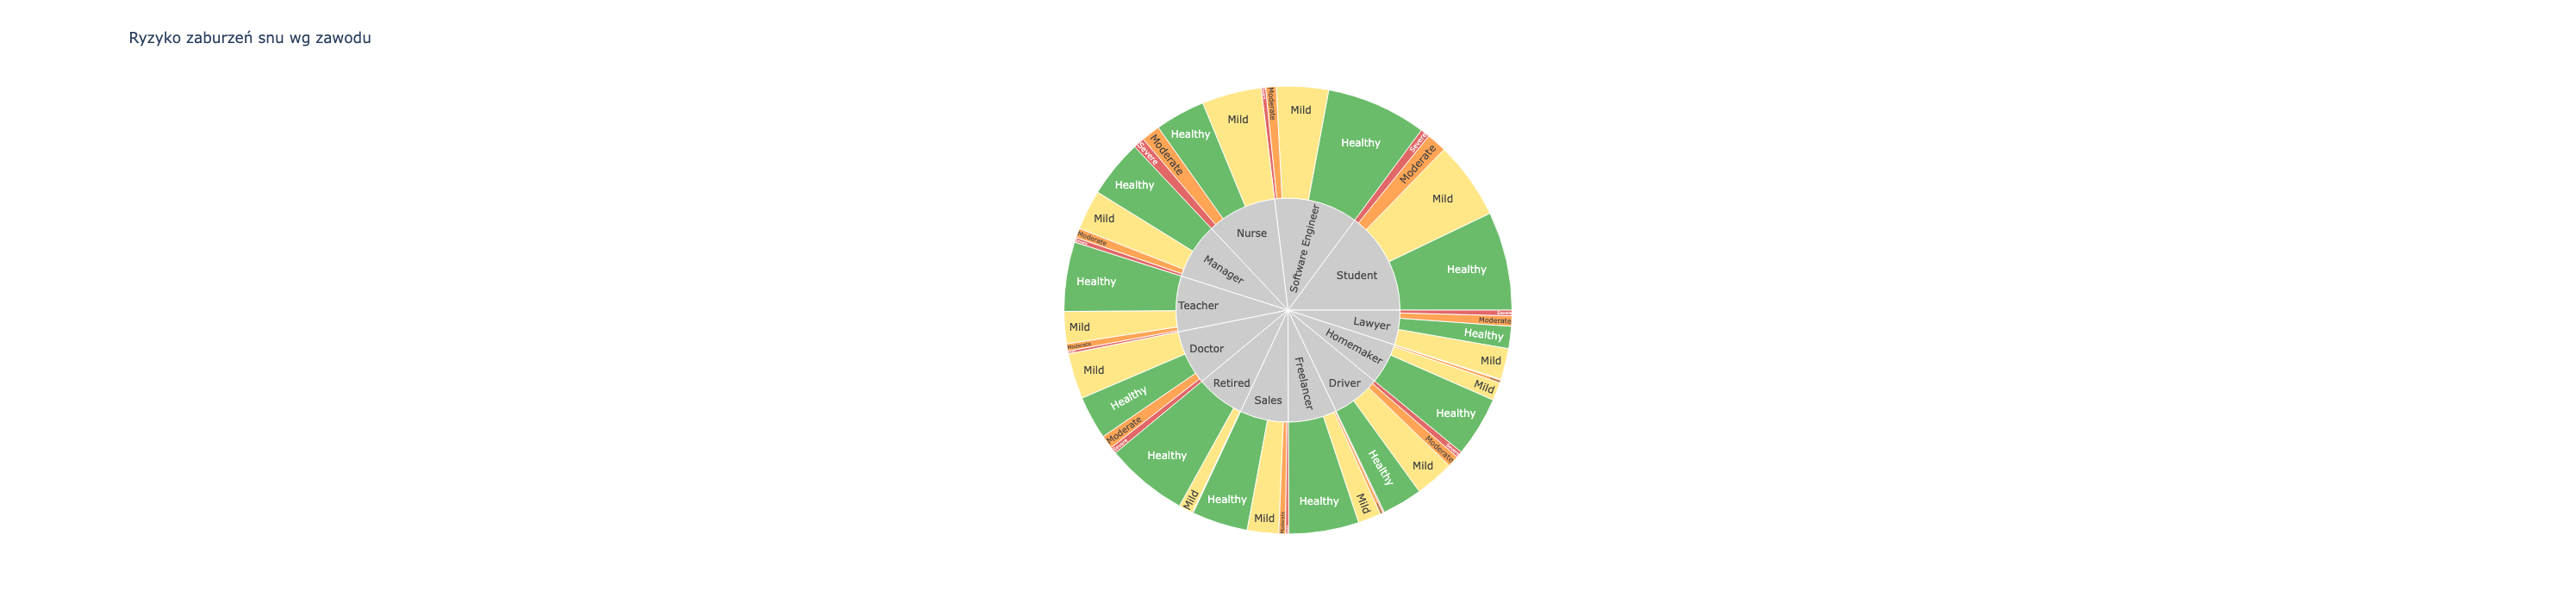

In [123]:
# Kopia wybranych kolumn, główny df zostaje bez zmian, zmieniamy category na str.
df_sunburst = df[["occupation", "sleep_disorder_risk"]].astype(str)

fig = px.sunburst(
    df_sunburst,
    path=["occupation", "sleep_disorder_risk"],
    color="sleep_disorder_risk",
    color_discrete_map={
        "Healthy": "#2ca02c",
        "Mild": "#ffdd57",
        "Moderate": "#ff7f0e",
        "Severe": "#d62728",
        "(?)": "#cccccc"
    },
    title="Ryzyko zaburzeń snu wg zawodu"
)
fig.update_layout(width=700, height=700)
fig.show()

Wykres pokazuje, jak ryzyko zaburzeń snu rozkłada się w obrębie zawodów. 
    
Emeryci mają pierścień niemal w całości zielony.

Odwrotnie wygląda to u pielęgniarek, prawników, lekarzy i kierowców, gdzie wyraźnie większy udział mają segmenty pomarańczowe i czerwone. Co pokazuje, że ryzyko zaburzeń idzie w parze ze stresującym charakterem pracy.

## Ryzyko zaburzeń snu

In [126]:
# Rozkład ryzyka zaburzeń snu w każdej grupie wiekowej
tabela = pd.crosstab(
    df["age_group"],
    df["sleep_disorder_risk"],
    normalize="index"
) * 100

tabela = tabela[["Healthy", "Mild", "Moderate", "Severe"]]
print(tabela.round(1))

sleep_disorder_risk  Healthy  Mild  Moderate  Severe
age_group                                           
18-29                   56.3  32.1       7.9     3.7
30-44                   54.7  33.4       8.1     3.9
45-59                   50.3  35.8       9.2     4.7
60+                     37.7  40.9      12.6     8.8


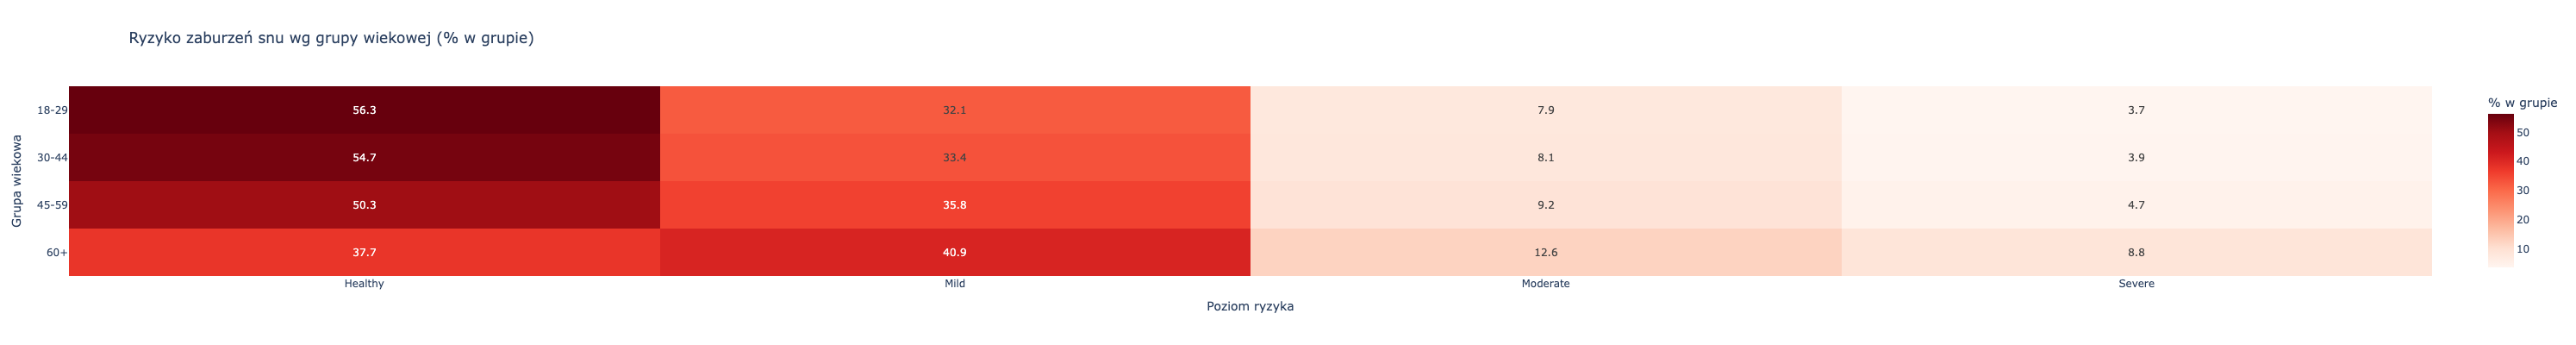

In [127]:
fig = px.imshow(
    tabela,
    text_auto=".1f",
    color_continuous_scale="Reds",
    aspect="auto",
    labels={
        "x": "Poziom ryzyka",
        "y": "Grupa wiekowa",
        "color": "% w grupie"
    },
    title="Ryzyko zaburzeń snu wg grupy wiekowej (% w grupie)"
)
fig.update_layout(template="plotly_white", width=700, height=400)
fig.show()

Ryzyko zaburzeń snu rośnie z wiekiem.

Odsetek osób zdrowych spada z 56% w grupie 18–29 do 38% wśród osób 60+, a jednocześnie ciężkie ryzyko rośnie z 3.7% do 8.8%. 
    
Wraz z wynikiem sunburst daje to pełny obraz grupy ryzyka - najbardziej zagrożeni są starsi oraz osoby w stresujących, zmianowych zawodach.

## 4. Zapis oczyszczonych danych

Zapis przygotowanego zbioru do pliku CSV. Posłuży on jako wejście do aplikacji Streamlit.

In [129]:
# Zapis oczyszczonego zbioru.
df.to_csv("sleep_clean.csv", index=False)

print("Zapisano sleep_clean.csv")
print("Wymiary:", df.shape)
print("Kolumny:", list(df.columns))

Zapisano sleep_clean.csv
Wymiary: (100000, 38)
Kolumny: ['person_id', 'age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested', 'caffeine_log', 'age_group', 'bmi_category', 'high_screen', 'enough_sleep', 'stress_group']
